# FoodSure AI — Adulteration Percentage Regression

## AI-Based Turmeric Adulteration Detection & Quantification

This notebook investigates whether machine-learning models can estimate the
adulteration percentage of turmeric samples using multimodal data.

Unlike the previous classification notebook, where the objective was to
identify one of seven discrete adulteration levels, this notebook treats
adulteration percentage as a continuous numerical target.

### Target Variable

The target represents the percentage of wheat flour adulteration:

- 0%
- 1%
- 2%
- 3%
- 5%
- 7%
- 9%

### Modalities

1. Color measurements
2. FTIR spectroscopy
3. EfficientNet-B0 image features

### Regression Metrics

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

### Key Principle

The same leakage-safe train/test split created during preprocessing is used
throughout this notebook.

No new random train/test split is created.

The objective is to evaluate how accurately each modality can estimate the
adulteration percentage on the fixed test set.

-----------------------------------------------------------------------------

## 2. Load Preprocessed Data

The preprocessing notebook generated scaled and PCA-reduced representations
for each modality.

The PCA-reduced representations are used for the baseline regression
experiments to keep the feature dimensions manageable.

The regression target is the numerical adulteration percentage.

In [670]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [671]:
y_train = pd.read_csv(
    "../preprocessed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "../preprocessed/y_test.csv"
).squeeze()

print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Training target shape: (280,)
Test target shape: (70,)


## 3. Verify Regression Target

Before training regression models, the target variable is checked to confirm
that it contains numerical adulteration percentages and that the same class
distribution is retained from the preprocessing stage.

In [672]:
print("Unique training targets:")
print(sorted(y_train.unique()))

print("\nUnique test targets:")
print(sorted(y_test.unique()))

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Unique training targets:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]

Unique test targets:
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(9.0)]

Training target distribution:
Adulteration_Percent
0.0    40
1.0    40
2.0    40
3.0    40
5.0    40
7.0    40
9.0    40
Name: count, dtype: int64

Test target distribution:
Adulteration_Percent
0.0    10
1.0    10
2.0    10
3.0    10
5.0    10
7.0    10
9.0    10
Name: count, dtype: int64


In [673]:
X_color_train_pca = pd.read_csv(
    "../preprocessed/X_color_train_pca.csv"
)

X_color_test_pca = pd.read_csv(
    "../preprocessed/X_color_test_pca.csv"
)

X_ftir_train_pca = pd.read_csv(
    "../preprocessed/X_ftir_train_pca.csv"
)

X_ftir_test_pca = pd.read_csv(
    "../preprocessed/X_ftir_test_pca.csv"
)

X_image_train_pca = pd.read_csv(
    "../preprocessed/X_image_train_pca.csv"
)

X_image_test_pca = pd.read_csv(
    "../preprocessed/X_image_test_pca.csv"
)

print("Color:", X_color_train_pca.shape, X_color_test_pca.shape)
print("FTIR:", X_ftir_train_pca.shape, X_ftir_test_pca.shape)
print("Image:", X_image_train_pca.shape, X_image_test_pca.shape)

Color: (280, 3) (70, 3)
FTIR: (280, 91) (70, 91)
Image: (280, 48) (70, 48)


## 4.1 Color + Linear Regression

Linear Regression is used as the first regression baseline for the Color
modality.

The model attempts to learn a linear relationship between the PCA-reduced
color features and the numerical adulteration percentage.

The same fixed training and test sets from the preprocessing stage are used.

In [674]:
color_linear = LinearRegression()

color_linear.fit(
    X_color_train_pca,
    y_train
)

y_color_linear_pred = color_linear.predict(
    X_color_test_pca
)

In [675]:
color_linear_mae = mean_absolute_error(
    y_test,
    y_color_linear_pred
)

color_linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_color_linear_pred
    )
)

color_linear_r2 = r2_score(
    y_test,
    y_color_linear_pred
)

print(f"MAE: {color_linear_mae:.4f}")
print(f"RMSE: {color_linear_rmse:.4f}")
print(f"R² Score: {color_linear_r2:.4f}")

MAE: 0.7380
RMSE: 0.9166
R² Score: 0.9093


MAE  → average absolute prediction error
RMSE → larger errors receive more penalty
R²   → how much target variation is explained by the model

### Interpretation

Color + Linear Regression achieved an MAE of 0.7380 percentage points and
an RMSE of 0.9166 percentage points on the fixed test set.

The R² score of 0.9093 indicates that the linear model explains approximately
90.93% of the variation in adulteration percentage within this evaluation.

The difference between MAE and RMSE indicates that some prediction errors are
larger than the typical absolute error, since RMSE gives greater weight to
larger deviations.

These results suggest that the color measurements contain substantial
information related to adulteration percentage in the controlled dataset.
However, performance on independent real-world samples may differ and
requires external validation.

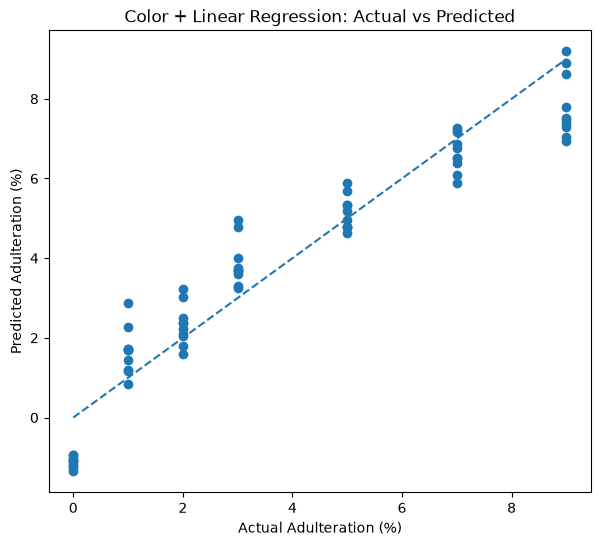

In [676]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_color_linear_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Color + Linear Regression: Actual vs Predicted")

plt.show()

### Plot Interpretation

The actual-versus-predicted plot shows that most predictions follow the
ideal diagonal relationship between actual and predicted adulteration
percentages.

Some deviations are visible, particularly at the lower and higher
adulteration levels. These deviations represent individual prediction errors.

Overall, the plot is consistent with the R² of 0.9093, indicating a strong
relationship between the predicted and actual values on the fixed test set.

-----------------------------------------------------------------------------

In [677]:
color_svr = SVR(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    epsilon=0.1
)

color_svr.fit(
    X_color_train_pca,
    y_train
)

y_color_svr_pred = color_svr.predict(
    X_color_test_pca
)

In [678]:
color_svr_mae = mean_absolute_error(
    y_test,
    y_color_svr_pred
)

color_svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_color_svr_pred
    )
)

color_svr_r2 = r2_score(
    y_test,
    y_color_svr_pred
)

print(f"MAE: {color_svr_mae:.4f}")
print(f"RMSE: {color_svr_rmse:.4f}")
print(f"R² Score: {color_svr_r2:.4f}")

MAE: 0.4005
RMSE: 0.5849
R² Score: 0.9631


### Interpretation

Color + SVR achieved an MAE of 0.4005 percentage points and an RMSE of
0.5849 percentage points on the fixed test set.

The R² score of 0.9631 indicates that the model explains approximately
96.31% of the variation in adulteration percentage within this evaluation.

Compared with the linear regression baseline, SVR produced lower MAE and RMSE
and a higher R² score. This indicates that the nonlinear RBF kernel captures
relationships in the color feature representation that are not fully captured
by the linear model.

These results are specific to the fixed test set from the controlled dataset
and should not be interpreted as evidence of equivalent performance on
independent real-world samples.

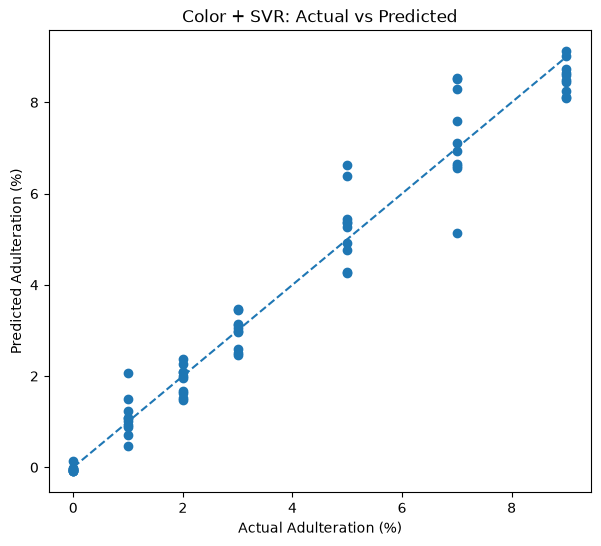

In [679]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_color_svr_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Color + SVR: Actual vs Predicted")

plt.show()

## 4.3 Color + Random Forest Regression

Random Forest Regressor is used as a nonlinear tree-based regression baseline
for the Color modality.

The model uses the same PCA-reduced color features and the same fixed
train/test split as the previous regression experiments.

In [680]:
color_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

color_rf.fit(
    X_color_train_pca,
    y_train
)

y_color_rf_pred = color_rf.predict(
    X_color_test_pca
)

In [681]:
color_rf_mae = mean_absolute_error(
    y_test,
    y_color_rf_pred
)

color_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_color_rf_pred
    )
)

color_rf_r2 = r2_score(
    y_test,
    y_color_rf_pred
)

print(f"MAE: {color_rf_mae:.4f}")
print(f"RMSE: {color_rf_rmse:.4f}")
print(f"R² Score: {color_rf_r2:.4f}")

MAE: 0.2766
RMSE: 0.5010
R² Score: 0.9729


### Interpretation

The Color + Random Forest Regressor achieved an MAE of 0.2766 percentage
points, an RMSE of 0.5010 percentage points, and an R² score of 0.9729 on
the fixed test set.

Among the three Color regression baselines, the Random Forest produced lower
MAE and RMSE and a higher R² than the Linear Regression and SVR models on
this evaluation.

This indicates that the tree-based model captures nonlinear relationships
within the PCA-reduced color representation effectively for this controlled
dataset.

The result is specific to the fixed test set and should not be interpreted
as evidence of equivalent performance on independent real-world samples.

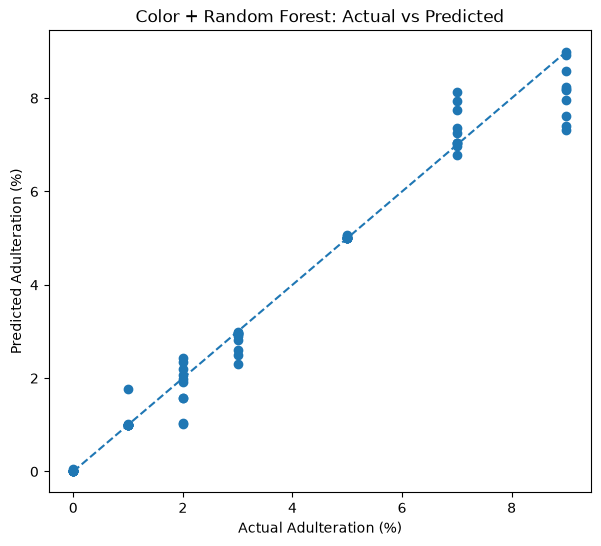

In [682]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_color_rf_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Color + Random Forest: Actual vs Predicted")

plt.show()

In [683]:
color_regression_results = pd.DataFrame([
    {
        "Modality": "Color",
        "Model": "Linear Regression",
        "MAE": color_linear_mae,
        "RMSE": color_linear_rmse,
        "R2": color_linear_r2
    },
    {
        "Modality": "Color",
        "Model": "SVR (RBF)",
        "MAE": color_svr_mae,
        "RMSE": color_svr_rmse,
        "R2": color_svr_r2
    },
    {
        "Modality": "Color",
        "Model": "Random Forest",
        "MAE": color_rf_mae,
        "RMSE": color_rf_rmse,
        "R2": color_rf_r2
    }
])

color_regression_results.round(4)

,Modality,Model,MAE,RMSE,R2
0,Color,Linear Regression,0.7380,0.9166,0.9093
1,Color,SVR (RBF),0.4005,0.5849,0.9631
2,Color,Random Forest,0.2766,0.5010,0.9729


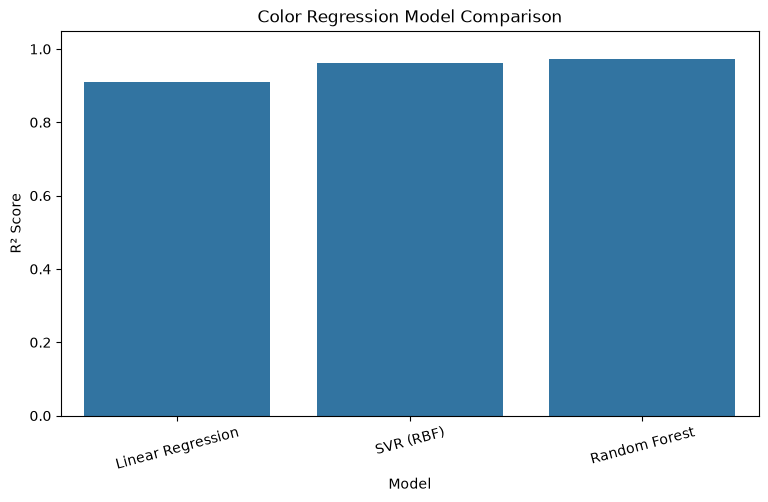

In [684]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=color_regression_results,
    x="Model",
    y="R2"
)

plt.ylim(0, 1.05)
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("Color Regression Model Comparison")
plt.xticks(rotation=15)
plt.show()

-----------------------------------------------------------------------------

## 5.1 FTIR + Linear Regression

Linear Regression is used as the first regression baseline for the FTIR
modality.

The model uses the PCA-reduced FTIR representation and predicts the numerical
adulteration percentage.

In [685]:
ftir_linear = LinearRegression()

ftir_linear.fit(
    X_ftir_train_pca,
    y_train
)

y_ftir_linear_pred = ftir_linear.predict(
    X_ftir_test_pca
)

In [686]:
ftir_linear_mae = mean_absolute_error(
    y_test,
    y_ftir_linear_pred
)

ftir_linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_ftir_linear_pred
    )
)

ftir_linear_r2 = r2_score(
    y_test,
    y_ftir_linear_pred
)

print(f"MAE: {ftir_linear_mae:.4f}")
print(f"RMSE: {ftir_linear_rmse:.4f}")
print(f"R² Score: {ftir_linear_r2:.4f}")

MAE: 0.2286
RMSE: 0.2979
R² Score: 0.9904


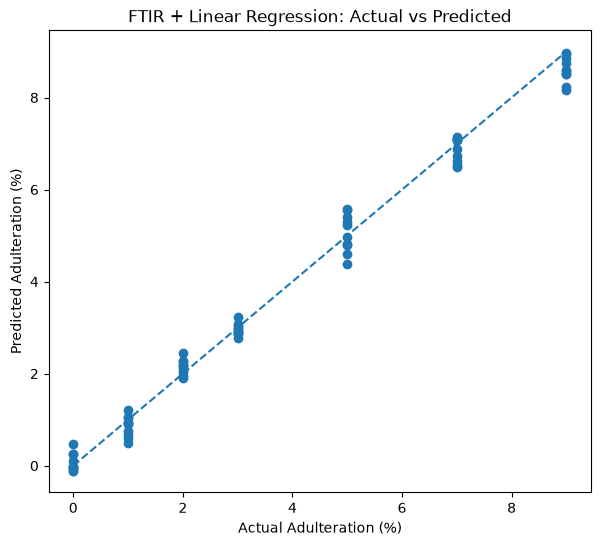

In [687]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_ftir_linear_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("FTIR + Linear Regression: Actual vs Predicted")

plt.show()

### Interpretation

FTIR + Linear Regression achieved an MAE of 0.2286 percentage points and an
RMSE of 0.2979 percentage points on the fixed test set.

The R² score of 0.9904 indicates that the model explains approximately 99.04%
of the variation in adulteration percentage within this evaluation.

The predictions are generally close to the ideal diagonal in the
actual-versus-predicted plot, indicating relatively small prediction errors.

The strong result suggests that the PCA-reduced FTIR representation contains
substantial information related to the controlled adulteration levels in this
dataset.

This result is specific to the current controlled dataset and fixed test
split and requires validation on independent physical samples before any
real-world interpretation.

-----------------------------------------------------------------------------

## 5.2 FTIR + Support Vector Regression

SVR with an RBF kernel is evaluated to determine whether nonlinear
relationships in the PCA-reduced FTIR representation can improve
adulteration-percentage estimation.

In [688]:
ftir_svr = SVR(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    epsilon=0.1
)

ftir_svr.fit(
    X_ftir_train_pca,
    y_train
)

y_ftir_svr_pred = ftir_svr.predict(
    X_ftir_test_pca
)

In [689]:
ftir_svr_mae = mean_absolute_error(
    y_test,
    y_ftir_svr_pred
)

ftir_svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_ftir_svr_pred
    )
)

ftir_svr_r2 = r2_score(
    y_test,
    y_ftir_svr_pred
)

print(f"MAE: {ftir_svr_mae:.4f}")
print(f"RMSE: {ftir_svr_rmse:.4f}")
print(f"R² Score: {ftir_svr_r2:.4f}")

MAE: 0.3662
RMSE: 0.5023
R² Score: 0.9728


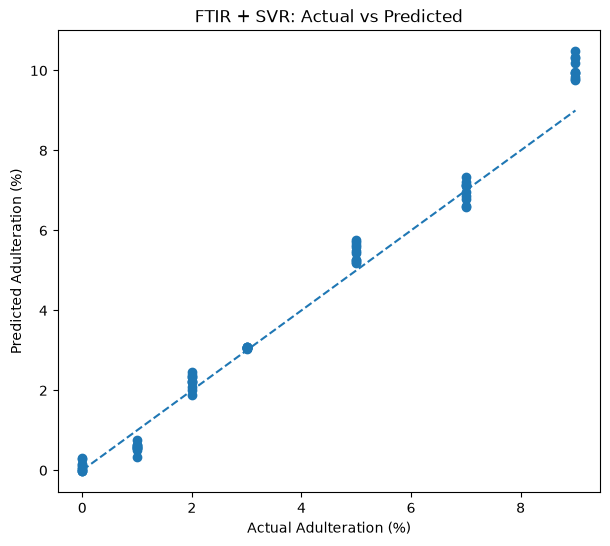

In [690]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_ftir_svr_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("FTIR + SVR: Actual vs Predicted")

plt.show()

### Plot Interpretation

The actual-versus-predicted plot compares the FTIR + SVR predictions with the
ideal diagonal relationship where predicted adulteration equals actual
adulteration.

Most predictions are relatively close to the diagonal, indicating that the
model captures the relationship between the FTIR representation and
adulteration percentage.

Some systematic deviations are visible. In particular, the predictions for
the 9% adulteration samples are generally above the ideal line, indicating
overestimation at the highest tested adulteration level. Smaller deviations
are also visible at other levels.

The plot is consistent with the MAE of 0.3662 percentage points and RMSE of
0.5023 percentage points. The R² score of 0.9728 indicates that the model
explains approximately 97.28% of the variation in adulteration percentage
within this fixed test-set evaluation.

These results are specific to the controlled dataset and fixed test split.
Independent physical samples would be required to assess generalization.

-----------------------------------------------------------------------------

## 5.3 FTIR + Random Forest Regression

Random Forest Regressor is evaluated as a nonlinear tree-based baseline for
the FTIR modality.

The model uses the PCA-reduced FTIR representation and the same fixed
train/test split used throughout the notebook.

In [691]:
ftir_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

ftir_rf.fit(
    X_ftir_train_pca,
    y_train
)

y_ftir_rf_pred = ftir_rf.predict(
    X_ftir_test_pca
)

In [692]:
ftir_rf_mae = mean_absolute_error(
    y_test,
    y_ftir_rf_pred
)

ftir_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_ftir_rf_pred
    )
)

ftir_rf_r2 = r2_score(
    y_test,
    y_ftir_rf_pred
)

print(f"MAE: {ftir_rf_mae:.4f}")
print(f"RMSE: {ftir_rf_rmse:.4f}")
print(f"R² Score: {ftir_rf_r2:.4f}")

MAE: 0.0112
RMSE: 0.0289
R² Score: 0.9999


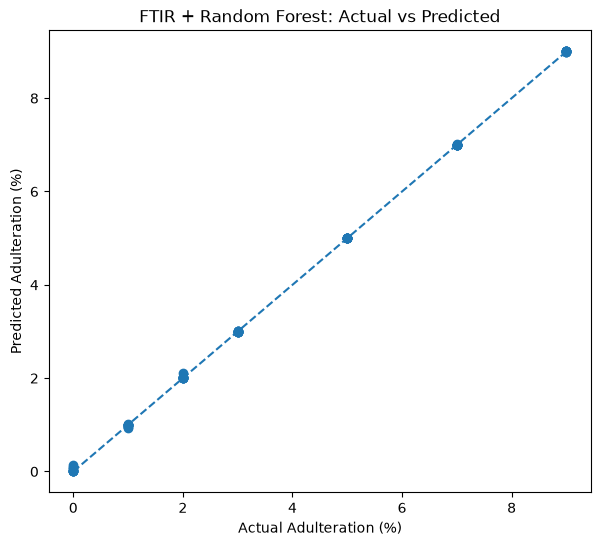

In [693]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_ftir_rf_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("FTIR + Random Forest: Actual vs Predicted")

plt.show()

### Interpretation

The FTIR + Random Forest Regressor achieved an MAE of 0.0112 percentage
points, an RMSE of 0.0289 percentage points, and an R² score of 0.9999 on
the fixed test set.

The extremely small MAE and RMSE indicate that the predicted adulteration
percentages are very close to the actual values for the evaluated test
samples. The R² score indicates that nearly all of the variation in the
target is explained within this particular evaluation.

The Random Forest result is substantially stronger than the Linear Regression
and SVR baselines for the current fixed test set.

However, the unusually high performance should be investigated carefully
before drawing conclusions about generalization. In particular, the result
should be checked against sample-level independence, preprocessing leakage,
duplicate or highly related measurements, and performance on independent
physical samples.

Therefore, this result is treated as strong experimental evidence on the
current controlled dataset rather than proof of equivalent real-world
performance.

In [694]:
ftir_regression_results = pd.DataFrame([
    {
        "Modality": "FTIR",
        "Model": "Linear Regression",
        "MAE": ftir_linear_mae,
        "RMSE": ftir_linear_rmse,
        "R2": ftir_linear_r2
    },
    {
        "Modality": "FTIR",
        "Model": "SVR (RBF)",
        "MAE": ftir_svr_mae,
        "RMSE": ftir_svr_rmse,
        "R2": ftir_svr_r2
    },
    {
        "Modality": "FTIR",
        "Model": "Random Forest",
        "MAE": ftir_rf_mae,
        "RMSE": ftir_rf_rmse,
        "R2": ftir_rf_r2
    }
])

ftir_regression_results.round(4)

,Modality,Model,MAE,RMSE,R2
0,FTIR,Linear Regression,0.2286,0.2979,0.9904
1,FTIR,SVR (RBF),0.3662,0.5023,0.9728
2,FTIR,Random Forest,0.0112,0.0289,0.9999


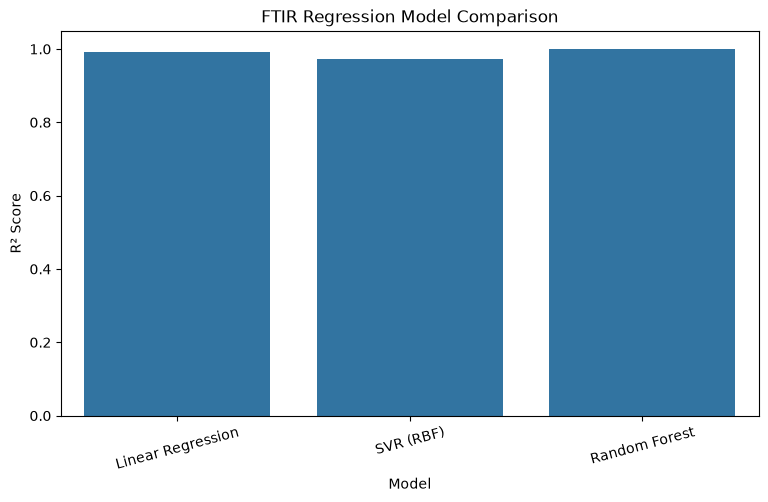

In [695]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=ftir_regression_results,
    x="Model",
    y="R2"
)

plt.ylim(0, 1.05)
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.title("FTIR Regression Model Comparison")
plt.xticks(rotation=15)

plt.show()

### FTIR Regression Summary

All three FTIR regression models produced strong performance on the fixed
test set.

Linear Regression achieved an R² of 0.9904, while SVR achieved an R² of
0.9728. Random Forest produced an R² of 0.9999 with an MAE of only 0.0112
percentage points.

The results demonstrate that the FTIR representation contains substantial
information associated with the controlled adulteration levels.

The exceptionally high Random Forest performance will be examined further
for possible dataset-specific effects, including feature structure,
sample-level independence, and generalization to unseen physical samples.

-----------------------------------------------------------------------------

## 6. Image Regression

This section evaluates whether EfficientNet-B0 image features can be used to
estimate the numerical adulteration percentage of turmeric samples.

The EfficientNet-B0 representation contains 1280 learned image features.
PCA was previously used during preprocessing to obtain a reduced
48-dimensional representation.

Three regression models are evaluated:

1. Linear Regression
2. Support Vector Regression (SVR)
3. Random Forest Regression

All models use the same fixed train/test split.

## 6.1 Image + Linear Regression

Linear Regression is used as the first baseline for the image modality.

The model learns a linear relationship between the PCA-reduced
EfficientNet-B0 image representation and the numerical adulteration
percentage.

In [696]:
image_linear = LinearRegression()

image_linear.fit(
    X_image_train_pca,
    y_train
)

y_image_linear_pred = image_linear.predict(
    X_image_test_pca
)

In [697]:
image_linear_mae = mean_absolute_error(
    y_test,
    y_image_linear_pred
)

image_linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_image_linear_pred
    )
)

image_linear_r2 = r2_score(
    y_test,
    y_image_linear_pred
)

print(f"MAE: {image_linear_mae:.4f}")
print(f"RMSE: {image_linear_rmse:.4f}")
print(f"R² Score: {image_linear_r2:.4f}")

MAE: 0.9559
RMSE: 1.2344
R² Score: 0.8355


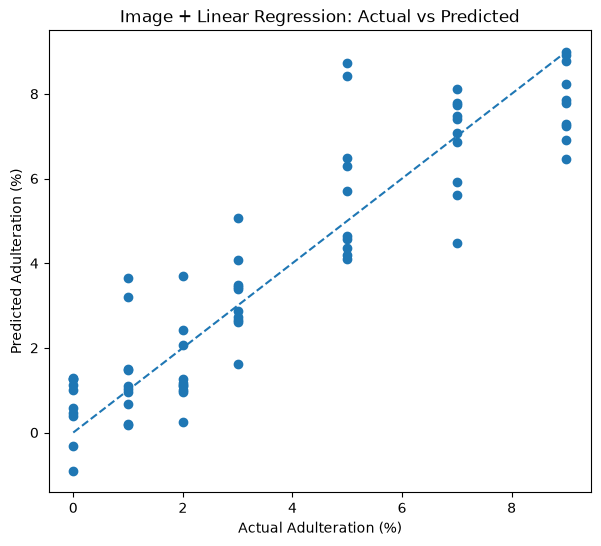

In [698]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_image_linear_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Image + Linear Regression: Actual vs Predicted")

plt.show()

From your graph:
- At 0%, predictions are spread around roughly -1 to 1.3%.
- At 1–2%, there is noticeable spread, so the model has difficulty estimating the exact percentage.
- At 3%, predictions are relatively close to the actual value.
- At 5%, there is substantial variation, with some predictions around 4–9%.
- At 7%, predictions range approximately from 4.5–8.1%.
- At 9%, predictions are mostly below the actual value, showing underestimation at the highest level.
- Overall, the points are more scattered around the diagonal than the FTIR plots we saw earlier.
Add this to the

### Interpretation

Image + Linear Regression achieved an MAE of 0.9559 percentage points and an
RMSE of 1.2344 percentage points on the fixed test set.

The R² score of 0.8355 indicates that approximately 83.55% of the variation
in adulteration percentage is explained by the linear regression model within
this evaluation.

Compared with the Color and FTIR regression baselines, the image
representation shows a weaker linear relationship with the adulteration
percentage.

This does not mean that image information is uninformative. The relationship
may be nonlinear, which motivates evaluating nonlinear regression models such
as SVR and Random Forest.

The result is specific to the controlled dataset and fixed test split.

## 6.2 Image + Support Vector Regression

SVR with an RBF kernel is evaluated to model potentially nonlinear
relationships between the PCA-reduced EfficientNet-B0 image features and
adulteration percentage.

In [699]:
image_svr = SVR(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    epsilon=0.1
)

image_svr.fit(
    X_image_train_pca,
    y_train
)

y_image_svr_pred = image_svr.predict(
    X_image_test_pca
)

In [700]:
image_svr_mae = mean_absolute_error(
    y_test,
    y_image_svr_pred
)

image_svr_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_image_svr_pred
    )
)

image_svr_r2 = r2_score(
    y_test,
    y_image_svr_pred
)

print(f"MAE: {image_svr_mae:.4f}")
print(f"RMSE: {image_svr_rmse:.4f}")
print(f"R² Score: {image_svr_r2:.4f}")

MAE: 1.1099
RMSE: 1.6895
R² Score: 0.6919


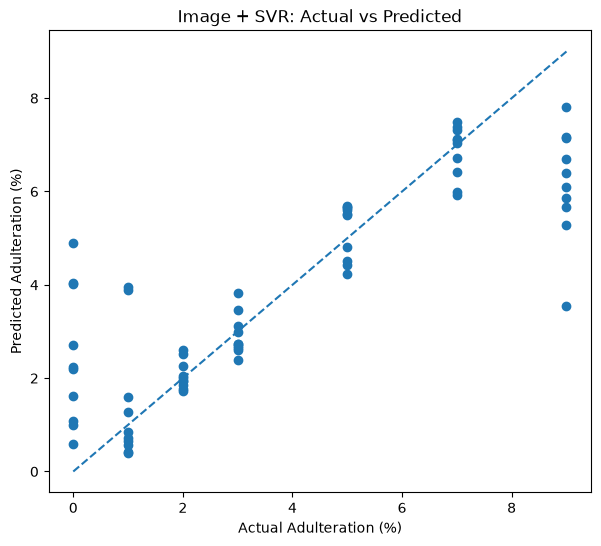

In [701]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_image_svr_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Image + SVR: Actual vs Predicted")

plt.show()

## 6.3 Image + Random Forest Regression

Random Forest Regressor is evaluated as a nonlinear tree-based model for
estimating adulteration percentage from the PCA-reduced EfficientNet-B0
image representation.

The same fixed train/test split is used for consistency with the previous
image regression experiments.

In [702]:
image_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

image_rf.fit(
    X_image_train_pca,
    y_train
)

y_image_rf_pred = image_rf.predict(
    X_image_test_pca
)

In [703]:
image_rf_mae = mean_absolute_error(
    y_test,
    y_image_rf_pred
)

image_rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_image_rf_pred
    )
)

image_rf_r2 = r2_score(
    y_test,
    y_image_rf_pred
)

print(f"MAE: {image_rf_mae:.4f}")
print(f"RMSE: {image_rf_rmse:.4f}")
print(f"R² Score: {image_rf_r2:.4f}")

MAE: 1.1574
RMSE: 1.7369
R² Score: 0.6744


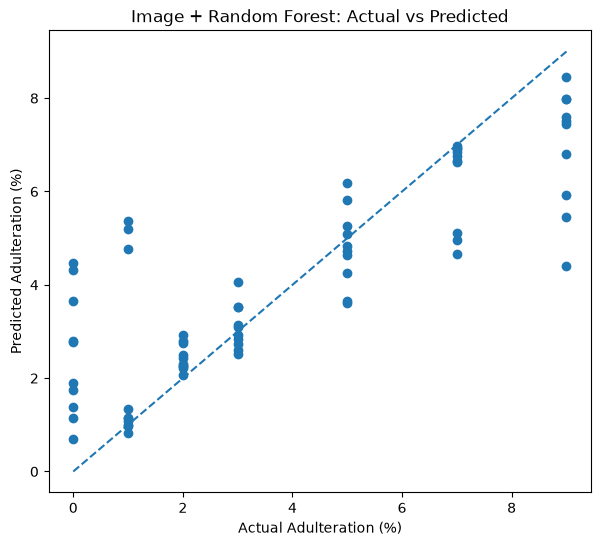

In [704]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_image_rf_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("Image + Random Forest: Actual vs Predicted")

plt.show()

### Interpretation

The Image + Random Forest model achieved an MAE of 1.1574 percentage points,
an RMSE of 1.7369 percentage points, and an R² score of 0.6744 on the fixed
test set.

Compared with the Image + Linear Regression and Image + SVR models, the
Random Forest model produced higher prediction errors and a lower R² score.

Interestingly, the nonlinear Random Forest and SVR models did not improve
upon the linear baseline for the image representation. This suggests that
the relationship between the current PCA-reduced EfficientNet-B0 features
and adulteration percentage is not necessarily better captured by these
nonlinear models under the current configurations.

These results are specific to the fixed test set and controlled dataset.
Further experiments with image preprocessing, feature representations, and
model tuning may provide additional information.

In [705]:
image_regression_results = pd.DataFrame([
    {
        "Modality": "Image",
        "Model": "Linear Regression",
        "MAE": image_linear_mae,
        "RMSE": image_linear_rmse,
        "R2": image_linear_r2
    },
    {
        "Modality": "Image",
        "Model": "SVR (RBF)",
        "MAE": image_svr_mae,
        "RMSE": image_svr_rmse,
        "R2": image_svr_r2
    },
    {
        "Modality": "Image",
        "Model": "Random Forest",
        "MAE": image_rf_mae,
        "RMSE": image_rf_rmse,
        "R2": image_rf_r2
    }
])

image_regression_results.round(4)

,Modality,Model,MAE,RMSE,R2
0,Image,Linear Regression,0.9559,1.2344,0.8355
1,Image,SVR (RBF),1.1099,1.6895,0.6919
2,Image,Random Forest,1.1574,1.7369,0.6744


## 6.5 Image Regression Summary

The three image-based regression models produced different levels of
performance on the fixed test set.

Linear Regression achieved an R² of 0.8355, while SVR achieved 0.6919 and
Random Forest achieved 0.6744.

The image representation therefore provides measurable information about
adulteration percentage, but the current image baselines show greater
prediction error than the corresponding Color and FTIR experiments.

The results should be interpreted within the context of the controlled
dataset and the EfficientNet-B0 feature representation used in this study.
Independent physical samples and additional image experiments are required
to evaluate generalization.

## 7. Overall Regression Comparison

This section combines the regression results from all three modalities:

1. Color measurements
2. FTIR spectroscopy
3. EfficientNet-B0 image features

Each modality was evaluated using the same three regression models:

- Linear Regression
- Support Vector Regression (SVR)
- Random Forest Regression

All models were evaluated on the same fixed test set of 70 samples.

The primary metrics are:

- MAE — Mean Absolute Error
- RMSE — Root Mean Squared Error
- R² — Coefficient of Determination

Lower MAE and RMSE indicate smaller prediction errors, while a higher R²
indicates that more variation in the target is explained by the model.

In [706]:
all_regression_results = pd.concat(
    [
        color_regression_results,
        ftir_regression_results,
        image_regression_results
    ],
    ignore_index=True
)

all_regression_results.round(4)

,Modality,Model,MAE,RMSE,R2
0,Color,Linear Regression,0.7380,0.9166,0.9093
1,Color,SVR (RBF),0.4005,0.5849,0.9631
2,Color,Random Forest,0.2766,0.5010,0.9729
3,FTIR,Linear Regression,0.2286,0.2979,0.9904
4,FTIR,SVR (RBF),0.3662,0.5023,0.9728
5,FTIR,Random Forest,0.0112,0.0289,0.9999
6,Image,Linear Regression,0.9559,1.2344,0.8355
7,Image,SVR (RBF),1.1099,1.6895,0.6919
8,Image,Random Forest,1.1574,1.7369,0.6744


In [707]:
all_regression_results[
    [
        "Modality",
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
].round(4)

,Modality,Model,MAE,RMSE,R2
0,Color,Linear Regression,0.7380,0.9166,0.9093
1,Color,SVR (RBF),0.4005,0.5849,0.9631
2,Color,Random Forest,0.2766,0.5010,0.9729
3,FTIR,Linear Regression,0.2286,0.2979,0.9904
4,FTIR,SVR (RBF),0.3662,0.5023,0.9728
5,FTIR,Random Forest,0.0112,0.0289,0.9999
6,Image,Linear Regression,0.9559,1.2344,0.8355
7,Image,SVR (RBF),1.1099,1.6895,0.6919
8,Image,Random Forest,1.1574,1.7369,0.6744


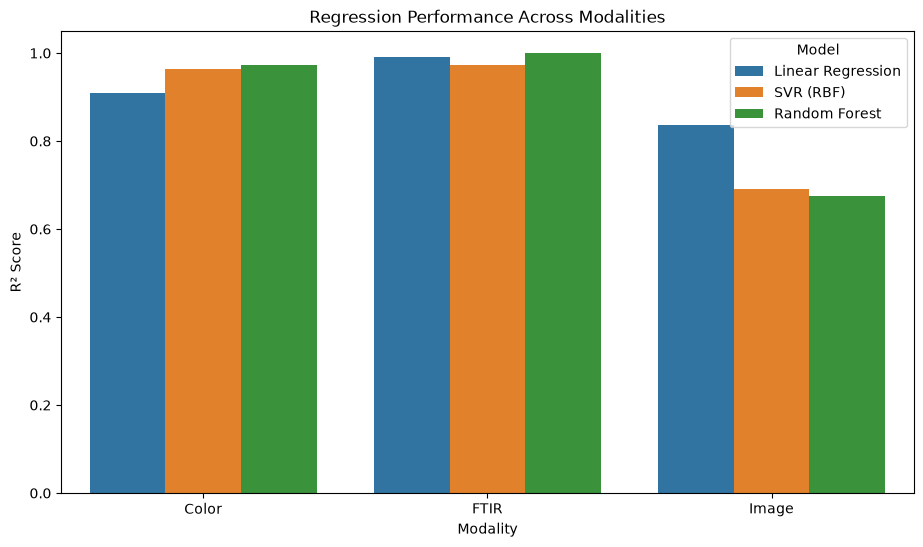

In [708]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=all_regression_results,
    x="Modality",
    y="R2",
    hue="Model"
)

plt.ylim(0, 1.05)
plt.xlabel("Modality")
plt.ylabel("R² Score")
plt.title("Regression Performance Across Modalities")

plt.show()

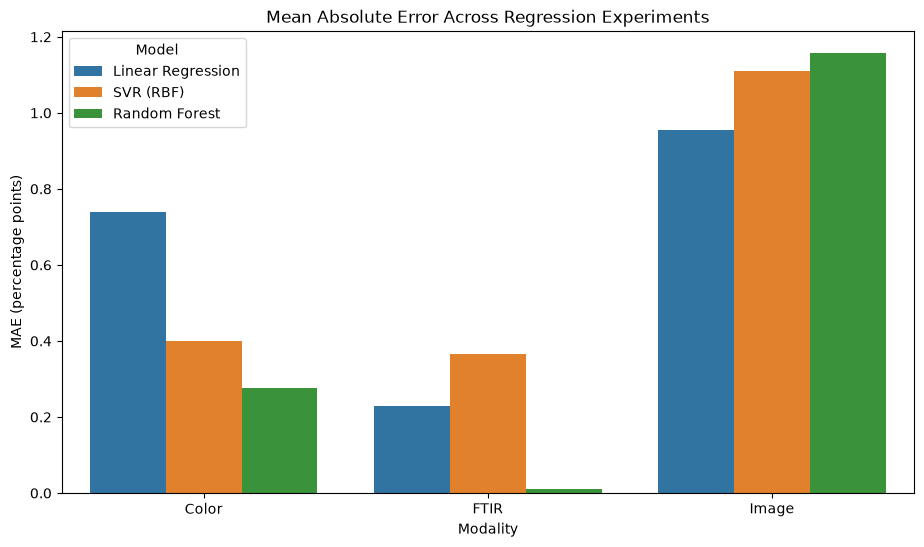

In [709]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=all_regression_results,
    x="Modality",
    y="MAE",
    hue="Model"
)

plt.xlabel("Modality")
plt.ylabel("MAE (percentage points)")
plt.title("Mean Absolute Error Across Regression Experiments")

plt.show()

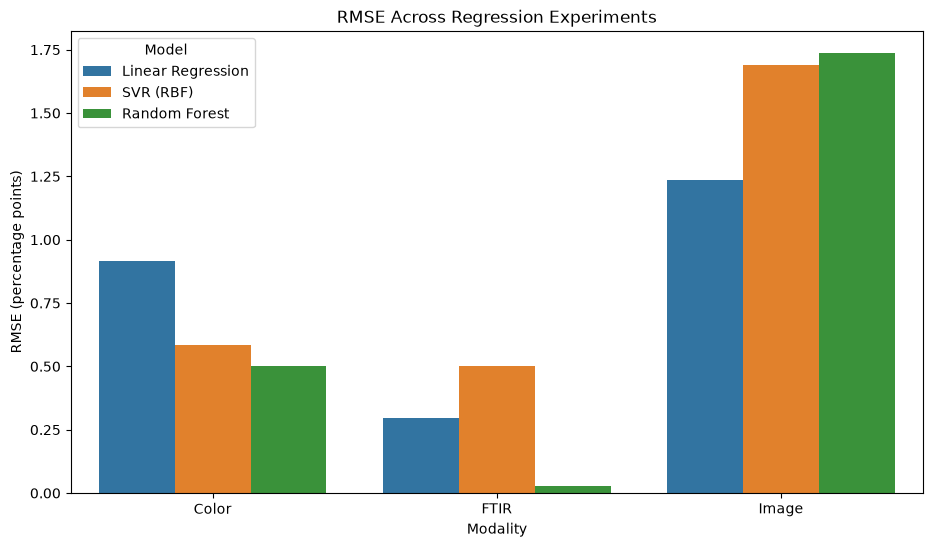

In [710]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=all_regression_results,
    x="Modality",
    y="RMSE",
    hue="Model"
)

plt.xlabel("Modality")
plt.ylabel("RMSE (percentage points)")
plt.title("RMSE Across Regression Experiments")

plt.show()

## 7.7 Overall Regression Interpretation

The combined regression experiments show that model performance varies
substantially across the three modalities.

The Color modality produced strong regression performance, particularly with
the nonlinear models.

The FTIR modality produced very strong performance across the evaluated
models. The Random Forest model achieved an R² of 0.9999 with an MAE of
0.0112 percentage points on the fixed test set.

The Image modality produced measurable but comparatively weaker regression
performance. Its Linear Regression model achieved an R² of 0.8355, while the
SVR and Random Forest models produced lower R² values under the current
configurations.

These results suggest that the controlled FTIR representation contains a
strong relationship with the adulteration levels present in this dataset.

However, the extremely high FTIR Random Forest performance requires careful
validation before making claims about generalization. Possible factors
including dataset structure, sample independence, feature representation,
and model-specific behavior should be investigated.

The results therefore describe performance on the current controlled dataset
and fixed test split rather than guaranteed performance on unseen real-world
samples.

----------------------------------------------------------------------------

Section 8 — Residual Analysis

## 8. Residual Analysis

Residual analysis is used to examine the prediction errors produced by the
regression models.

For each sample:

Residual = Actual Value − Predicted Value

A residual close to zero indicates a small prediction error.

Residual plots can help identify systematic errors, unusual observations,
and whether prediction errors increase at particular adulteration levels.

In [711]:
ftir_rf_residuals = y_test - y_ftir_rf_pred

print("Residual Summary:")
print(f"Mean Residual: {ftir_rf_residuals.mean():.6f}")
print(f"Minimum Residual: {ftir_rf_residuals.min():.6f}")
print(f"Maximum Residual: {ftir_rf_residuals.max():.6f}")

Residual Summary:
Mean Residual: -0.005476
Minimum Residual: -0.130000
Maximum Residual: 0.076667


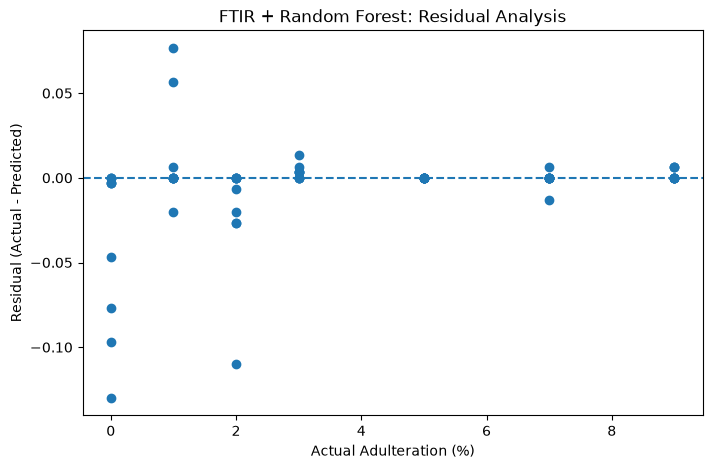

In [712]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    ftir_rf_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("FTIR + Random Forest: Residual Analysis")

plt.show()

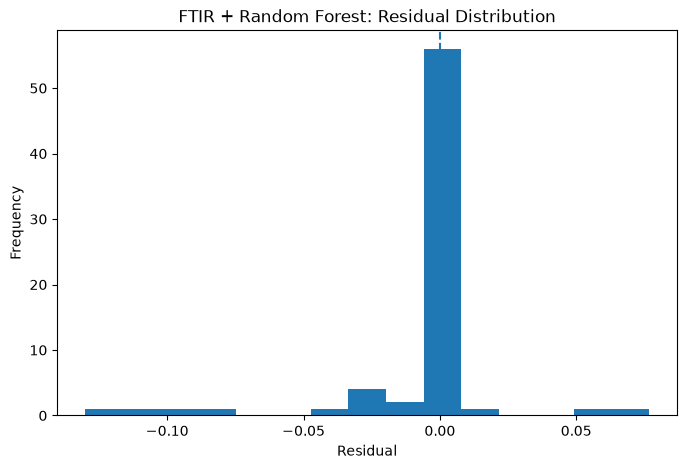

In [713]:
plt.figure(figsize=(8, 5))

plt.hist(
    ftir_rf_residuals,
    bins=15
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("FTIR + Random Forest: Residual Distribution")

plt.show()

### Residual Analysis Interpretation

The FTIR + Random Forest residual plot shows that most prediction errors are
closely concentrated around zero.

This indicates that the predicted adulteration percentages are very close to
the actual values for most samples in the fixed test set.

A small number of larger residuals are visible, particularly among the lower
adulteration levels. Both positive and negative residuals are present,
indicating that the model makes both underpredictions and overpredictions.

The residual distribution is strongly concentrated near zero, which is
consistent with the very low MAE of 0.0112 percentage points and RMSE of
0.0289 percentage points.

The residual analysis supports the strong performance observed for the FTIR
+ Random Forest model on this test set. However, the unusually small errors
should still be investigated for dataset-specific effects and validated using
independent physical samples before making claims about generalization.

## 8.2 Residual Comparison Across Modalities

To compare prediction error patterns across modalities, residuals are
calculated for the Random Forest regression model for Color, FTIR, and Image.

Using the same model family allows the residual behavior of the three
modalities to be compared under a common modeling approach.

In [714]:
color_rf_residuals = y_test - y_color_rf_pred
ftir_rf_residuals = y_test - y_ftir_rf_pred
image_rf_residuals = y_test - y_image_rf_pred

residual_summary = pd.DataFrame({
    "Modality": ["Color", "FTIR", "Image"],
    "Mean Residual": [
        color_rf_residuals.mean(),
        ftir_rf_residuals.mean(),
        image_rf_residuals.mean()
    ],
    "Mean Absolute Residual": [
        np.mean(np.abs(color_rf_residuals)),
        np.mean(np.abs(ftir_rf_residuals)),
        np.mean(np.abs(image_rf_residuals))
    ],
    "RMSE": [
        np.sqrt(np.mean(color_rf_residuals ** 2)),
        np.sqrt(np.mean(ftir_rf_residuals ** 2)),
        np.sqrt(np.mean(image_rf_residuals ** 2))
    ]
})

residual_summary.round(4)

,Modality,Mean Residual,Mean Absolute Residual,RMSE
0,Color,0.1168,0.2766,0.5010
1,FTIR,-0.0055,0.0112,0.0289
2,Image,-0.1883,1.1574,1.7369


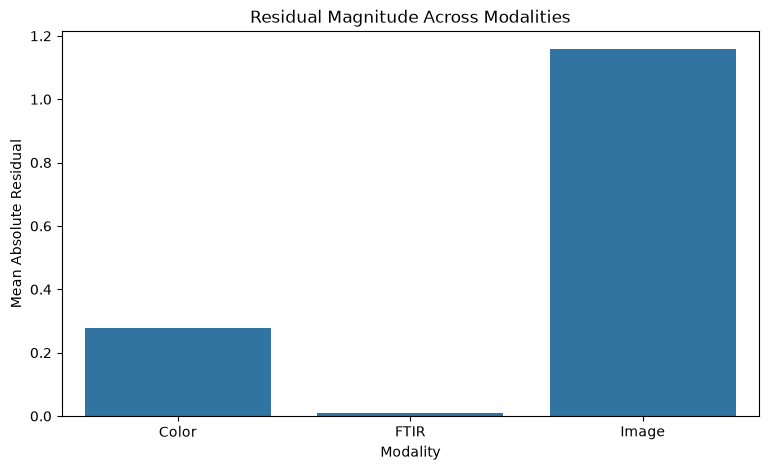

In [715]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=residual_summary,
    x="Modality",
    y="Mean Absolute Residual"
)

plt.ylabel("Mean Absolute Residual")
plt.xlabel("Modality")
plt.title("Residual Magnitude Across Modalities")

plt.show()

## 8.3 Error by Adulteration Level

Overall metrics such as MAE and RMSE summarize model performance across the
entire test set. However, they do not show whether prediction errors are
concentrated at particular adulteration levels.

Therefore, the absolute prediction error is examined separately for each
adulteration level.

This helps identify whether some concentration levels are more difficult
for the regression model to estimate.

In [716]:
error_by_level = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_ftir_rf_pred
})

error_by_level["Absolute_Error"] = (
    np.abs(
        error_by_level["Actual"] -
        error_by_level["Predicted"]
    )
)

level_error_summary = (
    error_by_level
    .groupby("Actual")["Absolute_Error"]
    .agg(["mean", "max", "count"])
    .reset_index()
)

level_error_summary.columns = [
    "Adulteration_Level",
    "Mean_Absolute_Error",
    "Maximum_Absolute_Error",
    "Samples"
]

level_error_summary.round(4)

,Adulteration_Level,Mean_Absolute_Error,Maximum_Absolute_Error,Samples
0,0.0,0.0360,0.1300,10
1,1.0,0.0160,0.0767,10
2,2.0,0.0190,0.1100,10
3,3.0,0.0033,0.0133,10
4,5.0,0.0000,0.0000,10
5,7.0,0.0020,0.0133,10
6,9.0,0.0020,0.0067,10


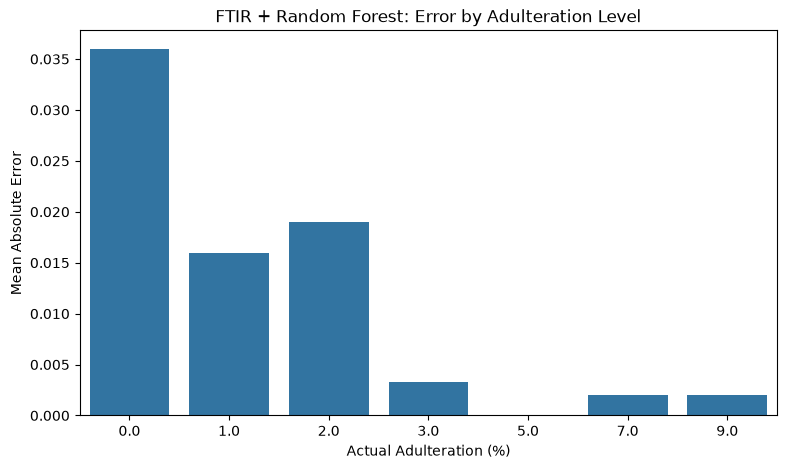

In [717]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=level_error_summary,
    x="Adulteration_Level",
    y="Mean_Absolute_Error"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Mean Absolute Error")
plt.title("FTIR + Random Forest: Error by Adulteration Level")

plt.show()

### Interpretation

The error-by-adulteration-level analysis shows that prediction errors are not
uniform across all adulteration levels.

The largest mean absolute error was observed for the 0% adulteration group,
followed by the 2% and 1% groups. The errors became substantially smaller at
3%, 5%, 7%, and 9%.

The 5% group had an approximately zero mean absolute error on the fixed test
set, indicating that the predictions for these samples were extremely close
to their actual values.

This pattern suggests that the current FTIR + Random Forest model estimates
the higher adulteration levels very closely in this controlled dataset, while
somewhat larger deviations occur at the lower levels.

These differences should not be interpreted as universal difficulty levels
for turmeric adulteration detection. They may depend on the characteristics
of this dataset, the selected samples, and the current model configuration.

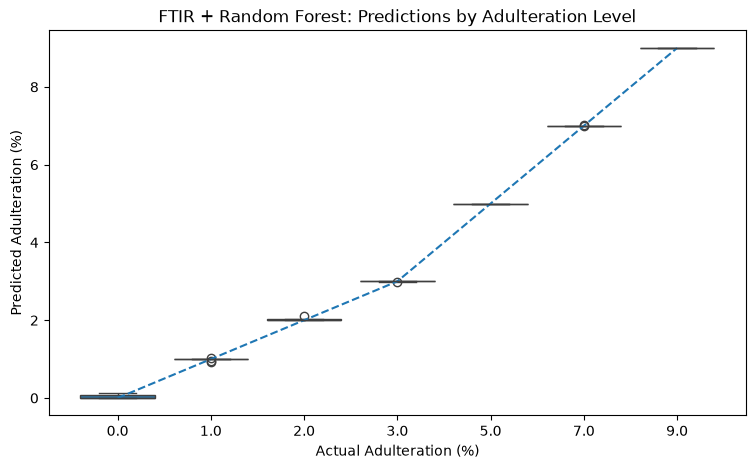

In [718]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=error_by_level,
    x="Actual",
    y="Predicted"
)

plt.plot(
    range(len(sorted(y_test.unique()))),
    sorted(y_test.unique()),
    linestyle="--"
)

plt.xlabel("Actual Adulteration (%)")
plt.ylabel("Predicted Adulteration (%)")
plt.title("FTIR + Random Forest: Predictions by Adulteration Level")

plt.show()

### Actual vs Predicted by Adulteration Level

The boxplot shows the distribution of predicted adulteration percentages
for each actual adulteration level.

Most prediction distributions are located close to the ideal prediction
line, indicating close agreement between actual and predicted values.

The prediction distributions are particularly concentrated around the 3%,
5%, 7%, and 9% levels. Somewhat greater variation is visible at the lower
adulteration levels.

Overall, this visualization is consistent with the very low regression
errors obtained by the FTIR + Random Forest model on the fixed test set.

The visualization represents performance on the controlled dataset and
should not be interpreted as evidence of equivalent performance on
independent real-world samples.

# 9. Regression Conclusion

The regression experiments evaluated the ability of Color measurements,
FTIR spectroscopy, and EfficientNet-B0 image features to estimate the
percentage of wheat-flour adulteration in turmeric samples.

Each modality was evaluated using Linear Regression, SVR, and Random Forest
Regression on the same fixed test set.

The experiments showed clear differences between the modalities.

Color measurements provided strong predictive information, with nonlinear
models achieving substantially better performance than the linear baseline.

FTIR spectroscopy produced the strongest regression results in the current
experiments. In particular, the FTIR + Random Forest model achieved an MAE
of 0.0112 percentage points, an RMSE of 0.0289 percentage points, and an
R² score of 0.9999 on the fixed test set.

The image-based representation produced measurable predictive information,
but its regression performance was lower under the current model
configurations. Image + Linear Regression achieved an R² of 0.8355, while
the SVR and Random Forest models achieved lower R² values.

Residual analysis showed that the FTIR + Random Forest predictions were
generally concentrated very close to the actual adulteration levels, with
the largest errors occurring mainly at lower adulteration levels.

These findings demonstrate that the evaluated spectral and color
representations contain useful information for estimating adulteration
percentage within this controlled dataset.

However, the very high FTIR performance should be interpreted cautiously.
Further validation using independent physical samples, repeated
experiments, and additional robustness testing is required before
generalizing these results to real-world turmeric samples.

The regression models are therefore considered part of an AI-assisted
research prototype for adulteration screening and estimation rather than a
replacement for laboratory verification.